

# Momentum Trading CC
### OPIM 5641 — Business Decision Modeling · Module1

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/_archive/MomentumTrading_CC.ipynb)

*Run me top to bottom — **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# Developing "Momentum" Trading Strategies
--------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Please note that this is not to be taken as financial advice, and that the basis of this notebook was not my original work. I used someone else's notebook to get things started, but then added my own comments, visualizations and exercises to the script to make it more accesible and relevant to the students. (**Carlos' note: and I made my edits on Prof. Wanik's original notebook!**)

Now, with that said, let's talk about a really slick application of moving average models and how it can be used in algorithmic trading! 💸 💰 🤑

* Many different takes on this strategy
* Sometimes referred to as trend following
* Whatever you do and call it, you first need to research potential trading signals


# References
This is the link to the original notebook:
* https://github.com/mjmacarty/alphavantage/blob/main/3-momentum_algorithmic.ipynb

And here is the corresponding YouTube video - pay attention to the discussion on 'data leakage' and 'look-ahead' at the end of the video! It's stunning.
* https://www.youtube.com/watch?v=fqltiq5EahU

**Disclaimer:** This should not be taken as financial advice, it is for demonstration purposes and useful as an exercise to test your Python for time series skills.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# some stock-specific packages
!pip install yahoo_fin
!pip install requests_html
import yahoo_fin.stock_info as si

### 1. Download data:
* Many services for this; some paid, some free
* Yahoo Finance API
* Typically trading "systems" involve a number of securities
* For this demonstration we are just going to look at GLD (gold)

In [ ]:
ticker = "GLD"
gld = si.get_data(ticker,start_date = '12/27/2017',end_date='01/22/2020',interval='1d')
day = np.arange(1, len(gld) + 1) #generate list of trading days
gld['Day'] = day
# Dropping columns I don't want to use
gld.drop(columns=['adjclose', 'volume','ticker'], inplace = True)
# Reorganizing the columns
gld = gld[['Day', 'open', 'high', 'low', 'close']]
# Renaming the columns
gld.columns = ['Day', 'Open', 'High', 'Low', 'Close']
gld.head()

,Day,Open,High,Low,Close
2017-12-27,1,122.000000,122.339996,121.879997,122.230003
2017-12-28,2,122.820000,122.919998,122.559998,122.849998
2017-12-29,3,123.699997,124.089996,123.459999,123.650002
2018-01-02,4,124.660004,125.180000,124.389999,125.150002
2018-01-03,5,125.050003,125.089996,124.099998,124.820000


In [ ]:
# shows the different data types
gld.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 519 entries, 2017-12-27 to 2020-01-21
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Day     519 non-null    int64  
 1   Open    519 non-null    float64
 2   High    519 non-null    float64
 3   Low     519 non-null    float64
 4   Close   519 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 24.3 KB


In [ ]:
# compute summary statistics of each column
gld.describe()

,Day,Open,High,Low,Close
count,519.000000,519.000000,519.000000,519.000000,519.000000
mean,260.000000,126.358998,126.779923,125.927592,126.354836
std,149.966663,9.518133,9.620097,9.402552,9.530570
min,1.000000,111.459999,111.879997,111.059998,111.099998
25%,130.500000,120.029999,120.340000,119.825001,120.085003
50%,260.000000,124.410004,124.760002,124.000000,124.489998
75%,389.500000,133.595001,134.284996,132.955002,133.665001
max,519.000000,148.490005,148.610001,147.429993,147.970001


### 2. Add data/transform data

We have two main goals next:
* Calculate a signal based on some price or statistical action
* We are going to try a moving average crossover to generate signals (when two moving averages cross each other)

You must be careful when computing the moving averages, though, as you may have data leakage on tomorrow's price! You can get a model that looks AMAZING by leaking data - but it won't be amazing when that model does not validate in the real-world.

* `gld['Close'].rolling(9).mean()` includes the 9th day.


In [ ]:
# WITH data leakage
# why is it leaking? It includes the 9th day!
gld['9-day'] = gld['Close'].rolling(9).mean()
gld['21-day'] = gld['Close'].rolling(21).mean()
gld.head(n=10)

<ipython-input-121-922fe9716ef1>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gld['9-day'] = gld['Close'].rolling(9).mean()
<ipython-input-121-922fe9716ef1>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gld['21-day'] = gld['Close'].rolling(21).mean()


,Day,Open,High,Low,Close,9-day,21-day
2017-12-27,1,122.000000,122.339996,121.879997,122.230003,NaN,NaN
2017-12-28,2,122.820000,122.919998,122.559998,122.849998,NaN,NaN
2017-12-29,3,123.699997,124.089996,123.459999,123.650002,NaN,NaN
2018-01-02,4,124.660004,125.180000,124.389999,125.150002,NaN,NaN
2018-01-03,5,125.050003,125.089996,124.099998,124.820000,NaN,NaN
2018-01-04,6,124.889999,125.849998,124.739998,125.459999,NaN,NaN
2018-01-05,7,124.930000,125.480003,124.830002,125.330002,NaN,NaN
2018-01-08,8,125.199997,125.320000,124.900002,125.309998,NaN,NaN
2018-01-09,9,124.489998,124.860001,124.230003,124.730003,124.392223,NaN
2018-01-10,10,125.169998,125.309998,124.720001,125.029999,124.703334,NaN


* `gld['Close'].rolling(9).mean().shift()` uses the previous 9 day moving average to make its decision for tomorrow's trading day

In [ ]:
# rolled back (no data leakage)
# since this cell is run after, this overwrites the previous data leakage
# you can comment out the cell above and run all if you are nervous!
gld['9-day'] = gld['Close'].rolling(9).mean().shift()
gld['21-day'] = gld['Close'].rolling(21).mean().shift()
gld.dropna(inplace=True)
gld.head(n=10)

,Day,Open,High,Low,Close,9-day,21-day
2018-01-29,22,127.580002,127.629997,126.919998,127.349998,127.154445,125.778572
2018-01-30,23,127.910004,127.919998,126.739998,126.800003,127.174445,126.022381
2018-01-31,24,127.449997,127.849998,126.400002,127.650002,127.247779,126.210477
2018-02-01,25,127.180000,128.149994,127.080002,128.070007,127.446668,126.400953
2018-02-02,26,126.809998,126.849998,125.959999,126.389999,127.630002,126.540001
2018-02-05,27,126.820000,127.309998,126.440002,126.709999,127.601113,126.614763
2018-02-06,28,126.540001,126.550003,125.220001,125.379997,127.537780,126.674287
2018-02-07,29,125.480003,125.769997,124.410004,124.790001,127.154446,126.676667
2018-02-08,30,124.919998,125.440002,124.510002,124.980003,126.801113,126.651906
2018-02-09,31,124.650002,125.139999,124.389999,124.769997,126.457779,126.663810


## Visualize what the moving averages look like
See where the lines first cross - the 9 day price is dipping below the 21 day price - this means it's time to sell!

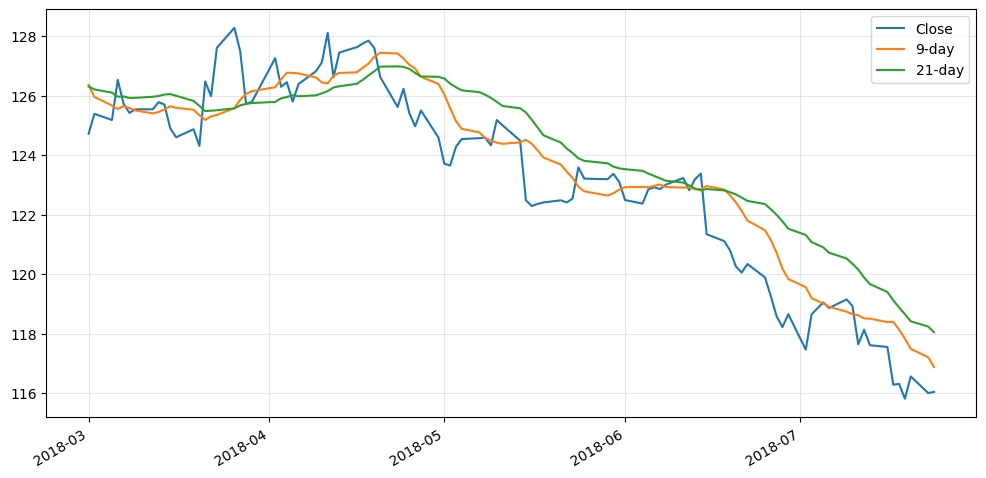

In [ ]:
# imagine where you would put markers on the plot
# for buy vs. sell...

# the 22:123 shows the first 100 days of trading
gld.iloc[22:123,[4,5,6]].plot(figsize=(12,6))
plt.grid(True, alpha = .3)
plt.show()

Did you picture something like this? Below is an embedded picture that I'll show you how to make at the end of the notebook!

## Develop a trading strategy based on moving averages
* When the 9-day price is less than the 21-day price, sell the stock!
* When the 21-day price is less than the 9-day price, buy the stock!
* The transactions take place when the trend "shifts" (i.e., **only** when the plots cross)

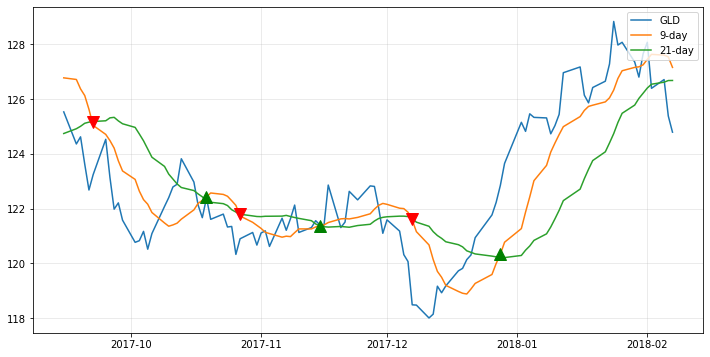

Looking at this first 100 days (after the 21 day warm-up period), we see some really nice trades and  some suboptimal trades. But overall this looks reasonable!

# Buy and Hold strategy

The function `.diff()` calculates the difference between the current row and previous row. That's why there is a `NaN` at the beginning of the dataframe when we create the `gld['return']` column.

We want to calculate the returns using `.diff()`, so we need to take the log of the close values. `gld['return']` will be the **'buy and hold' return** (i.e., we will buy in the first day and sell in the last day, regardless of what's happening in the market). And later, we will make a variable for our system, the momentum trading algorithm!

In [ ]:
gld['logClose'] = np.log(gld['Close']) # price will always be positive, so this operation is well-defined
gld['return'] = gld['logClose'].diff() # the difference will be positive or negative
gld.head()

,Day,Open,High,Low,Close,9-day,21-day,logClose,return
2018-01-29,22,127.580002,127.629997,126.919998,127.349998,127.154445,125.778572,4.846939,NaN
2018-01-30,23,127.910004,127.919998,126.739998,126.800003,127.174445,126.022381,4.842611,-0.004328
2018-01-31,24,127.449997,127.849998,126.400002,127.650002,127.247779,126.210477,4.849292,0.006681
2018-02-01,25,127.180000,128.149994,127.080002,128.070007,127.446668,126.400953,4.852577,0.003285
2018-02-02,26,126.809998,126.849998,125.959999,126.389999,127.630002,126.540001,4.839372,-0.013205


In this case, instead of deleting the first row, I prefer to set a return of 0, so let's do that.

In [ ]:
gld.loc["2018-01-29",'return'] = 0.0
gld.head()

,Day,Open,High,Low,Close,9-day,21-day,logClose,return
2018-01-29,22,127.580002,127.629997,126.919998,127.349998,127.154445,125.778572,4.846939,0.000000
2018-01-30,23,127.910004,127.919998,126.739998,126.800003,127.174445,126.022381,4.842611,-0.004328
2018-01-31,24,127.449997,127.849998,126.400002,127.650002,127.247779,126.210477,4.849292,0.006681
2018-02-01,25,127.180000,128.149994,127.080002,128.070007,127.446668,126.400953,4.852577,0.003285
2018-02-02,26,126.809998,126.849998,125.959999,126.389999,127.630002,126.540001,4.839372,-0.013205


Finally, what is the return of the buy&hold strategy?

In [ ]:
np.exp(np.sum(gld['return'])) -1

0.15225761485174494

# Momentum trading strategy



### Add "invested" column  
The purpose of this column is to show whether we are currently investing money or if we are out of the market. More precisely, **invested = 1 if the 9-day average is greater than the 21-day average**.

In [ ]:
# the np.where() function is similar to the Excel =IF() statement
gld['invested'] = np.where(gld['9-day'] > gld['21-day'], 1, 0)
gld.head()

,Day,Open,High,Low,Close,9-day,21-day,logClose,return,invested
2018-01-29,22,127.580002,127.629997,126.919998,127.349998,127.154445,125.778572,4.846939,0.000000,1
2018-01-30,23,127.910004,127.919998,126.739998,126.800003,127.174445,126.022381,4.842611,-0.004328,1
2018-01-31,24,127.449997,127.849998,126.400002,127.650002,127.247779,126.210477,4.849292,0.006681,1
2018-02-01,25,127.180000,128.149994,127.080002,128.070007,127.446668,126.400953,4.852577,0.003285,1
2018-02-02,26,126.809998,126.849998,125.959999,126.389999,127.630002,126.540001,4.839372,-0.013205,1


In [ ]:
print(gld['invested'].value_counts())

1    268
0    230
Name: invested, dtype: int64


### Entering and leaving the market using the momentum trading strategy

Now we make a column called 'signal' which tells you when you enter and leave the market based on the momentum trading strategy. Remember that we want to **buy/sell at the transition points**, i.e., when the plots are intersecting and the trend is changing.

A value of +1 indicates that we should buy, and a value of -1 indicates that we should sell. Observe that this happens when the trend flips.


In [ ]:
# the variable signal tells you when you buy and sell
# we will use it to make red and green triangles
gld['signal'] = gld['invested'].diff()
print(gld['signal'].value_counts())

 0.0    471
-1.0     13
 1.0     13
Name: signal, dtype: int64


Let's see how the dataframe is looking like at the moment:

In [ ]:
gld.head() # check your work

,Day,Open,High,Low,Close,9-day,21-day,logClose,return,invested,signal
2018-01-29,22,127.580002,127.629997,126.919998,127.349998,127.154445,125.778572,4.846939,0.000000,1,NaN
2018-01-30,23,127.910004,127.919998,126.739998,126.800003,127.174445,126.022381,4.842611,-0.004328,1,0.0
2018-01-31,24,127.449997,127.849998,126.400002,127.650002,127.247779,126.210477,4.849292,0.006681,1,0.0
2018-02-01,25,127.180000,128.149994,127.080002,128.070007,127.446668,126.400953,4.852577,0.003285,1,0.0
2018-02-02,26,126.809998,126.849998,125.959999,126.389999,127.630002,126.540001,4.839372,-0.013205,1,0.0


Ugly first line again. Let's set signal to 1, i.e., we want to buy on the first trading day:

In [ ]:
gld.loc["2018-01-29",'signal'] = 1.0
gld.head()

,Day,Open,High,Low,Close,9-day,21-day,logClose,return,invested,signal
2018-01-29,22,127.580002,127.629997,126.919998,127.349998,127.154445,125.778572,4.846939,0.000000,1,1.0
2018-01-30,23,127.910004,127.919998,126.739998,126.800003,127.174445,126.022381,4.842611,-0.004328,1,0.0
2018-01-31,24,127.449997,127.849998,126.400002,127.650002,127.247779,126.210477,4.849292,0.006681,1,0.0
2018-02-01,25,127.180000,128.149994,127.080002,128.070007,127.446668,126.400953,4.852577,0.003285,1,0.0
2018-02-02,26,126.809998,126.849998,125.959999,126.389999,127.630002,126.540001,4.839372,-0.013205,1,0.0


## Let's see the trading days

In [ ]:
gld[gld['signal'].isin([1,-1])]

,Day,Open,High,Low,Close,9-day,21-day,logClose,return,invested,signal
2018-01-29,22,127.580002,127.629997,126.919998,127.349998,127.154445,125.778572,4.846939,0.000000,1,1.0
2018-02-09,31,124.650002,125.139999,124.389999,124.769997,126.457779,126.663810,4.826472,-0.001682,0,-1.0
2018-02-26,41,126.449997,126.620003,126.180000,126.449997,126.706668,126.632858,4.839847,0.002455,1,1.0
2018-03-02,45,125.669998,125.690002,124.970001,125.389999,125.955555,126.209524,4.831429,0.005358,0,-1.0
2018-03-26,61,128.050003,128.580002,128.009995,128.279999,125.581111,125.570952,4.854215,0.005237,1,1.0
2018-04-27,84,125.199997,125.620003,125.169998,125.500000,126.632222,126.644286,4.832306,0.004232,0,-1.0
2018-06-14,117,123.629997,123.860001,123.320000,123.379997,122.860001,122.817620,4.815269,0.001541,1,1.0
2018-06-19,120,120.809998,121.029999,120.580002,120.800003,122.651111,122.755715,4.794136,-0.002563,0,-1.0
2018-09-04,173,112.750000,113.070000,112.610001,112.930000,113.585554,113.504285,4.726768,-0.005123,1,1.0
2018-09-20,185,114.209999,114.370003,113.860001,114.269997,113.497778,113.501904,4.738564,0.003419,0,-1.0


## System return

Let's see now how much money this is strategy is making (or losing!!!). Note that our investment will only change when we are invested.

In [ ]:
# The 'system_return' tells you how much money you would have made
# using your momentum trading algorithm!
gld['system_return'] = gld['invested'] * gld['return']
gld.head()

,Day,Open,High,Low,Close,9-day,21-day,logClose,return,invested,signal,system_return
2018-01-29,22,127.580002,127.629997,126.919998,127.349998,127.154445,125.778572,4.846939,0.000000,1,1.0,0.000000
2018-01-30,23,127.910004,127.919998,126.739998,126.800003,127.174445,126.022381,4.842611,-0.004328,1,0.0,-0.004328
2018-01-31,24,127.449997,127.849998,126.400002,127.650002,127.247779,126.210477,4.849292,0.006681,1,0.0,0.006681
2018-02-01,25,127.180000,128.149994,127.080002,128.070007,127.446668,126.400953,4.852577,0.003285,1,0.0,0.003285
2018-02-02,26,126.809998,126.849998,125.959999,126.389999,127.630002,126.540001,4.839372,-0.013205,1,0.0,-0.013205


What was the return of this trategy?

In [ ]:
np.exp(np.sum(gld['system_return'])) -1

0.09692285881908091

Let's recall the returns of the buy&hold strategy:

In [ ]:
np.exp(np.sum(gld['return'])) -1

0.15225761485174494

## Plot trades on time series for the last year

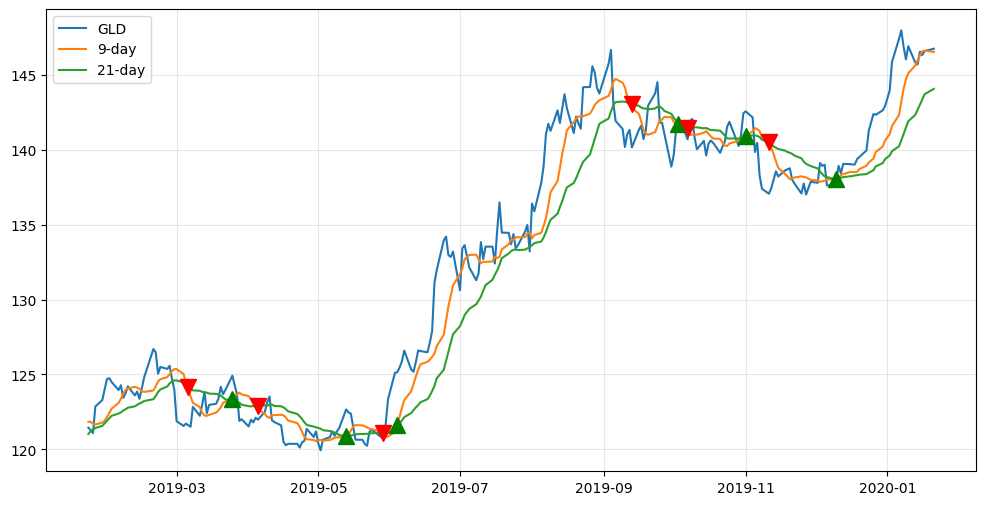

In [ ]:
# show the last year
plt.rcParams['figure.figsize'] = 12, 6
plt.grid(True, alpha = .3)
plt.plot(gld.iloc[-252:]['Close'], label = 'GLD') # actual value
plt.plot(gld.iloc[-252:]['9-day'], label = '9-day') # 9-day average
plt.plot(gld.iloc[-252:]['21-day'], label = '21-day') # 21-day average
plt.plot(gld[-252:].loc[gld.signal == 1].index, gld[-252:]['9-day'][gld.signal == 1], '^',
         color = 'g', markersize = 12)
plt.plot(gld[-252:].loc[gld.signal == -1].index, gld[-252:]['21-day'][gld.signal == -1], 'v',
         color = 'r', markersize = 12)
plt.legend(loc=2);

## Plot trades on time series for the entire time horizon

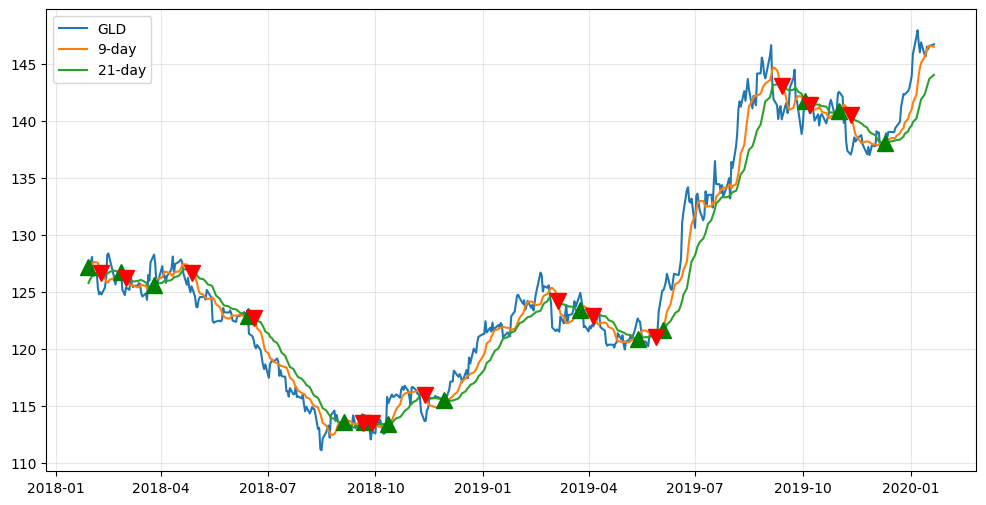

In [ ]:
# show all time
# if you squint closely you should see 34 red triangles
# and 34 green triangles!
plt.rcParams['figure.figsize'] = 12, 6
plt.grid(True, alpha = .3)
plt.plot(gld.iloc[:]['Close'], label = 'GLD')
plt.plot(gld.iloc[:]['9-day'], label = '9-day')
plt.plot(gld.iloc[:]['21-day'], label = '21-day')
plt.plot(gld[:].loc[gld.signal == 1].index, gld[:]['9-day'][gld.signal == 1], '^',
         color = 'g', markersize = 12)
plt.plot(gld[:].loc[gld.signal == -1].index, gld[:]['21-day'][gld.signal == -1], 'v',
         color = 'r', markersize = 12)
plt.legend(loc=2);

# Organize the Dataframe

We've calculated a lot of intermediate columns of data. Let's rearrange the order of the columns so that it's easier for us to tell a story.

In [ ]:
# print the column names so that we can copy/paste
gld.columns

Index(['Day', 'Open', 'High', 'Low', 'Close', '9-day', '21-day', 'logClose',
       'return', 'invested', 'signal', 'system_return'],
      dtype='object')

Convenient command to know: reordering the columns of a dataframe.

In [ ]:
# reorder the columns by name
# make a copy of gld with a new order of columns
gld = gld[['Day', 'Open', 'High', 'Low', 'Close',
           '9-day', '21-day',
           'invested', 'logClose',
          'return',
          'signal',  'system_return']]

Another convenient command: allowing Colab to display all the rows of your DataFrame

In [ ]:
pd.set_option("display.max_rows", None)
gld

,Day,Open,High,Low,Close,9-day,21-day,invested,logClose,return,signal,system_return
2018-01-29,22,127.580002,127.629997,126.919998,127.349998,127.154445,125.778572,1,4.846939,0.000000,1.0,0.000000
2018-01-30,23,127.910004,127.919998,126.739998,126.800003,127.174445,126.022381,1,4.842611,-0.004328,0.0,-0.004328
2018-01-31,24,127.449997,127.849998,126.400002,127.650002,127.247779,126.210477,1,4.849292,0.006681,0.0,0.006681
2018-02-01,25,127.180000,128.149994,127.080002,128.070007,127.446668,126.400953,1,4.852577,0.003285,0.0,0.003285
2018-02-02,26,126.809998,126.849998,125.959999,126.389999,127.630002,126.540001,1,4.839372,-0.013205,0.0,-0.013205
2018-02-05,27,126.820000,127.309998,126.440002,126.709999,127.601113,126.614763,1,4.841901,0.002529,0.0,0.002529
2018-02-06,28,126.540001,126.550003,125.220001,125.379997,127.537780,126.674287,1,4.831349,-0.010552,0.0,-0.010552
2018-02-07,29,125.480003,125.769997,124.410004,124.790001,127.154446,126.676667,1,4.826632,-0.004717,0.0,-0.004717
2018-02-08,30,124.919998,125.440002,124.510002,124.980003,126.801113,126.651906,1,4.828154,0.001521,0.0,0.001521
2018-02-09,31,124.650002,125.139999,124.389999,124.769997,126.457779,126.663810,0,4.826472,-0.001682,-1.0,-0.000000


# Compare the strategies!

The plot below compares the performance of the Buy&Hold strategy with the Momentum Trading strategy.

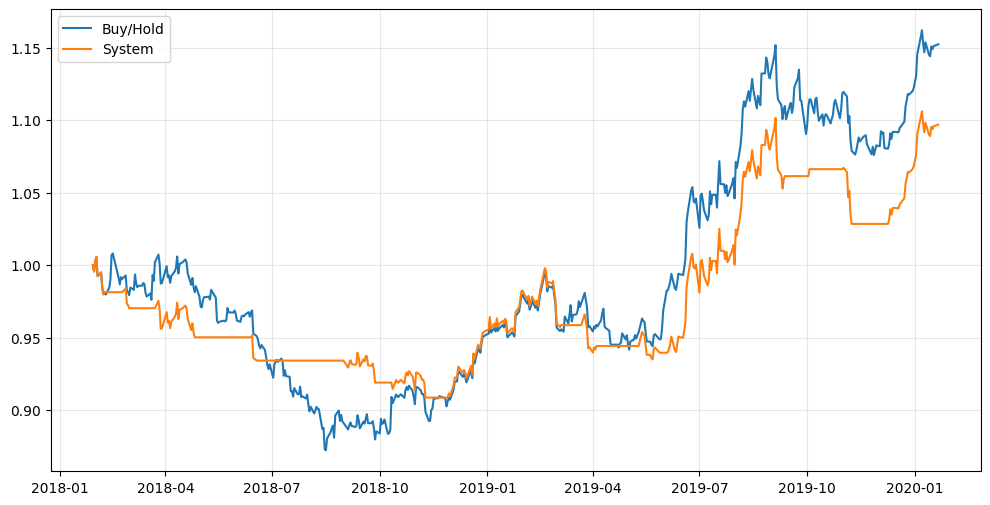

In [ ]:
plt.plot(np.exp(gld['return']).cumprod(), label='Buy/Hold')
plt.plot(np.exp(gld['system_return']).cumprod(), label='System')
plt.legend(loc=2)
plt.grid(True, alpha=.3)
plt.show()

# Closing Thoughts
* Try to complete all 'on your own' exercises that are in this notebook.
* Try a for loop for all possible numbers between 10 and 300 for short and long and see if you can find an 'optimal' combination of values. Then try it on a few other stocks to see if this really holds true!

# Alternative way of computing the returns (optional)

You don't like logs + sums? Use the exp() function to get the original values and work with products instead.

In [ ]:
# adding a few steps here for clarity
# 'r' is for return (buy and hold)
gld['r_cumprod'] = np.exp(gld['return'])
gld['exp_r_cumprod'] = gld['r_cumprod'].cumprod()

# 's' is for system (algo trading!)
gld['s_cumprod'] = np.exp(gld['system_return'])
gld['exp_s_cumprod'] = gld['s_cumprod'].cumprod()
gld.head()

,Day,Open,High,Low,Close,9-day,21-day,invested,logClose,return,signal,system_return,r_cumprod,exp_r_cumprod,s_cumprod,exp_s_cumprod
2018-01-29,22,127.580002,127.629997,126.919998,127.349998,127.154445,125.778572,1,4.846939,0.000000,1.0,0.000000,1.000000,1.000000,1.000000,1.000000
2018-01-30,23,127.910004,127.919998,126.739998,126.800003,127.174445,126.022381,1,4.842611,-0.004328,0.0,-0.004328,0.995681,0.995681,0.995681,0.995681
2018-01-31,24,127.449997,127.849998,126.400002,127.650002,127.247779,126.210477,1,4.849292,0.006681,0.0,0.006681,1.006703,1.002356,1.006703,1.002356
2018-02-01,25,127.180000,128.149994,127.080002,128.070007,127.446668,126.400953,1,4.852577,0.003285,0.0,0.003285,1.003290,1.005654,1.003290,1.005654
2018-02-02,26,126.809998,126.849998,125.959999,126.389999,127.630002,126.540001,1,4.839372,-0.013205,0.0,-0.013205,0.986882,0.992462,0.986882,0.992462


Observe that the plot below is identical to the previous one, and so are the final results.

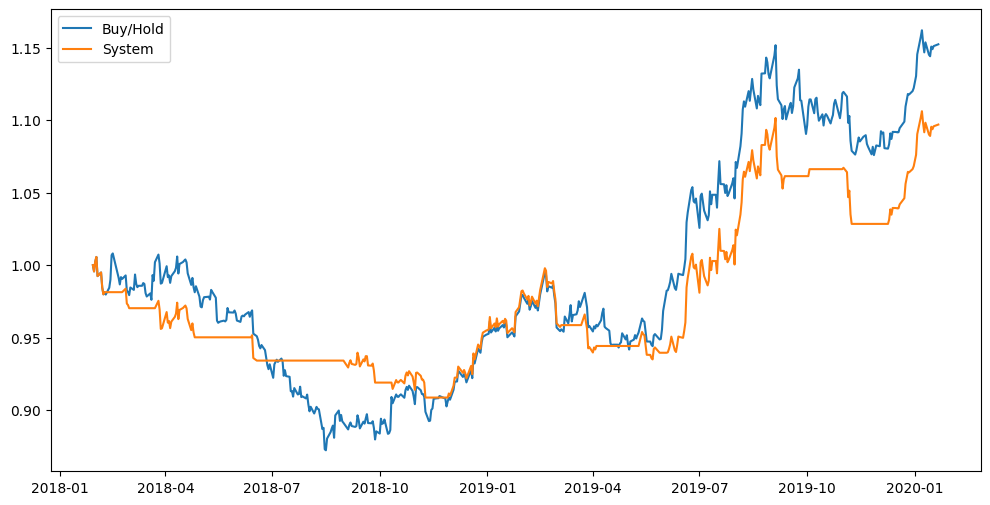

In [ ]:
# using our duplicative columns...
# we get the same things!
# ...be careful of the order of operations!
plt.plot(gld['exp_r_cumprod'], label='Buy/Hold')
plt.plot(gld['exp_s_cumprod'], label='System')
plt.legend(loc=2)
#plt.grid(True, alpha=.3)ChildProcessError

In [ ]:
np.exp(gld['return']).cumprod()[-1] -1

0.15225761485174583

In [ ]:
np.exp(gld['system_return']).cumprod()[-1] -1

0.09692285881907936

# Suggestions of exercises (optional)

- Get rid of hard-coded of values: Try something like `upperVal` and `lowerVal` and get rid of the 9s and 21s. You should also be careful of any nefarious hard-coded referencing like `[:-252]`... this is a hard-coded value!